# Visual Quality Module — Upgraded for 0.70–0.80 Accuracy

**Key upgrades over previous version:**
- EfficientNet-B2 backbone (stronger than ResNet18)
- Late fusion: image features + AADB tabular attributes combined
- Label smoothing (reduces overconfidence)
- Cosine annealing LR schedule (no verbose arg error)
- Early stopping with patience
- Test-time augmentation (TTA) at inference
- Correct label thresholds (score is 0–1, not 0–10)
- Stratified split + weighted sampler

In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Set up paths: use output directory for artifacts
OUTPUT_DIR = './outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Download AADB dataset using kagglehub (auto-cached locally)
print('\nDownloading AADB dataset...')
import kagglehub
DATA_PATH = kagglehub.dataset_download("bogdanpetre98/aadb-imagedatabase")
print(f'Dataset path: {DATA_PATH}')

csv_path   = os.path.join(DATA_PATH, 'Dataset.csv')
img_dir    = os.path.join(DATA_PATH, 'datasetImages_warp256', 'datasetImages_warp256')

print(f'\nDataset files:')
for item in os.listdir(DATA_PATH):
    print(f'  {item}')
print(f'\nCSV: {csv_path}')
print(f'IMG: {img_dir}')

Device: cpu

Dataset path: C:\Users\MSI\.cache\kagglehub\datasets\bogdanpetre98\aadb-imagedatabase\versions\6

Dataset files:
  Dataset.csv
  datasetImages_warp256
  Dataset_test.csv

CSV: C:\Users\MSI\.cache\kagglehub\datasets\bogdanpetre98\aadb-imagedatabase\versions\6\Dataset.csv
IMG: C:\Users\MSI\.cache\kagglehub\datasets\bogdanpetre98\aadb-imagedatabase\versions\6\datasetImages_warp256\datasetImages_warp256


## Step 1 — Load data and verify score range

In [3]:
df = pd.read_csv(csv_path)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nScore range: {df["score"].min():.4f} to {df["score"].max():.4f}')
print(f'Score mean:  {df["score"].mean():.4f}')
print(f'Score std:   {df["score"].std():.4f}')
print()
df.head(3)

Shape: (8958, 13)
Columns: ['ImageFile', 'BalacingElements', 'ColorHarmony', 'Content', 'DoF', 'Light', 'MotionBlur', 'Object', 'Repetition', 'RuleOfThirds', 'Symmetry', 'VividColor', 'score']

Score range: 0.0000 to 1.0000
Score mean:  0.5112
Score std:   0.1839



,ImageFile,BalacingElements,ColorHarmony,Content,DoF,Light,MotionBlur,Object,Repetition,RuleOfThirds,Symmetry,VividColor,score
0,farm1_333_19438364933_087c8abc60_b.jpg,-0.2,0.2,-0.2,-0.4,0.0,0.0,-0.4,0.0,-0.2,0.0,0.0,0.3
1,farm1_452_19898743300_201156d984_b.jpg,0.2,0.4,0.6,-0.2,0.2,0.0,0.6,0.0,0.8,0.0,0.4,0.7
2,farm1_281_20247100976_c8141d3653_b.jpg,-0.2,0.0,0.4,-0.2,-0.4,0.0,-0.6,0.0,-0.4,0.0,0.6,0.4


## Step 2 — Labels + tabular attribute normalization

**Two strategies used together:**
- Quantile-based labels → balanced classes
- Tabular attributes normalized to [0,1] → fed into fusion model

Class boundaries: bad < 0.4500 | average [0.4500, 0.6000] | good > 0.6000

Class distribution:
  Class 0: 2854 (31.9%)
  Class 1: 2768 (30.9%)
  Class 2: 3336 (37.2%)

Attribute columns (11): ['BalacingElements', 'ColorHarmony', 'Content', 'DoF', 'Light', 'MotionBlur', 'Object', 'Repetition', 'RuleOfThirds', 'Symmetry', 'VividColor']
Attribute range: -1.00 to 1.00

Top attribute correlations with score:
Content             0.681
Light               0.569
ColorHarmony        0.562
Object              0.542
VividColor          0.514
DoF                 0.437
RuleOfThirds        0.353
BalacingElements    0.332
MotionBlur          0.217
Symmetry            0.129
Repetition          0.100


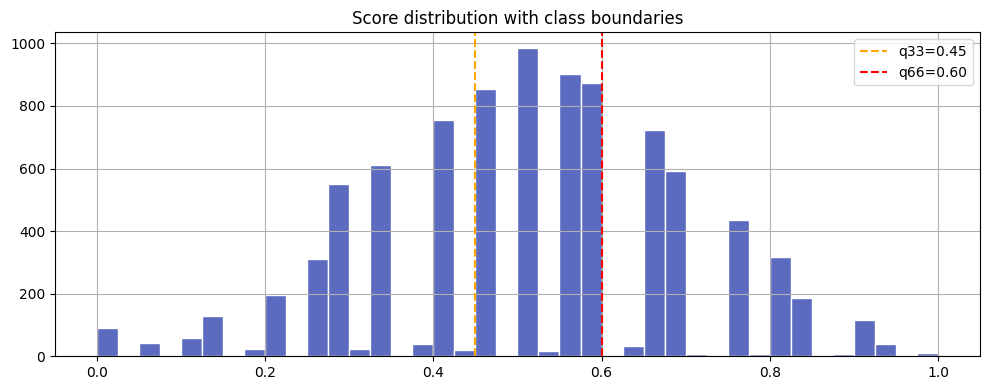

In [4]:
# ── Quantile-based labels (balanced classes, correct scale)
q33 = df['score'].quantile(0.33)
q66 = df['score'].quantile(0.66)
print(f'Class boundaries: bad < {q33:.4f} | average [{q33:.4f}, {q66:.4f}] | good > {q66:.4f}')

def make_label(s):
    if s < q33:  return 0
    if s < q66:  return 1
    return 2

df['label'] = df['score'].apply(make_label)

print('\nClass distribution:')
for cls in [0,1,2]:
    n = (df['label']==cls).sum()
    print(f'  Class {cls}: {n} ({n/len(df)*100:.1f}%)')

# ── AADB attribute columns (human-rated per aesthetic dimension)
ATTR_COLS = [c for c in [
    'BalacingElements','ColorHarmony','Content','DoF',
    'Light','MotionBlur','Object','Repetition',
    'RuleOfThirds','Symmetry','VividColor'
] if c in df.columns]

print(f'\nAttribute columns ({len(ATTR_COLS)}): {ATTR_COLS}')
print(f'Attribute range: {df[ATTR_COLS].min().min():.2f} to {df[ATTR_COLS].max().max():.2f}')

# Normalize each attribute from [-1,1] to [0,1]
for col in ATTR_COLS:
    cmin, cmax = df[col].min(), df[col].max()
    df[f'{col}_n'] = (df[col] - cmin) / (cmax - cmin + 1e-8)

ATTR_NORM = [f'{c}_n' for c in ATTR_COLS]
N_ATTRS = len(ATTR_NORM)

# Overall score normalized to [0,1]
smin, smax = df['score'].min(), df['score'].max()
df['score_n'] = (df['score'] - smin) / (smax - smin)

# Quick correlation check: which attributes matter most?
corr = df[ATTR_COLS + ['score']].corr()['score'].drop('score').sort_values(key=abs, ascending=False)
print('\nTop attribute correlations with score:')
print(corr.round(3).to_string())

with open(f'{OUTPUT_DIR}attribute_importance.json','w') as f:
    json.dump(corr.abs().to_dict(), f, indent=2)

# Plot
fig, ax = plt.subplots(figsize=(10,4))
df['score'].hist(bins=40, ax=ax, color='#5c6bc0', edgecolor='white')
ax.axvline(q33, color='orange', linestyle='--', label=f'q33={q33:.2f}')
ax.axvline(q66, color='red',    linestyle='--', label=f'q66={q66:.2f}')
ax.set_title('Score distribution with class boundaries')
ax.legend()
plt.tight_layout(); plt.show()

In [5]:
# Save the normalization stats used during training
# These are REQUIRED at inference to normalize raw attribute values
# the same way the model was trained

attr_norm_stats = {}
for col in ATTR_COLS:
    attr_norm_stats[col] = {
        'min': float(df[col].min()),
        'max': float(df[col].max()),
    }

# Save to disk — load this at inference time
with open(f'{OUTPUT_DIR}attr_norm_stats.json', 'w') as f:
    json.dump(attr_norm_stats, f, indent=2)

print('Normalization stats saved:')
for col, stats in attr_norm_stats.items():
    print(f'  {col:20s}: min={stats["min"]:.2f}  max={stats["max"]:.2f}')

print(f'\nSaved → {OUTPUT_DIR}attr_norm_stats.json')
print('IMPORTANT: Always load this file before calling predict_aesthetic()')

Normalization stats saved:
  BalacingElements    : min=-1.00  max=1.00
  ColorHarmony        : min=-1.00  max=1.00
  Content             : min=-1.00  max=1.00
  DoF                 : min=-1.00  max=1.00
  Light               : min=-1.00  max=1.00
  MotionBlur          : min=-1.00  max=1.00
  Object              : min=-1.00  max=1.00
  Repetition          : min=0.00  max=1.00
  RuleOfThirds        : min=-0.80  max=1.00
  Symmetry            : min=0.00  max=1.00
  VividColor          : min=-1.00  max=1.00

Saved → ./outputs/attr_norm_stats.json
IMPORTANT: Always load this file before calling predict_aesthetic()


## Step 3 — Filter valid images + stratified split

In [6]:
print('Checking which images exist on disk...')
df['img_path'] = df['ImageFile'].apply(lambda f: os.path.join(img_dir, f))
df['exists']   = df['img_path'].apply(os.path.exists)

missing = (~df['exists']).sum()
print(f'Images found: {df["exists"].sum()} / {len(df)}  (missing: {missing})')

df = df[df['exists']].reset_index(drop=True)
print(f'Working dataset: {len(df)} rows')

# Stratified split: 70% train | 15% val | 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f'\nSplit: train={len(train_df)} | val={len(val_df)} | test={len(test_df)}')
print('Class distribution per split:')
for name, split in [('train',train_df),('val',val_df),('test',test_df)]:
    d = split['label'].value_counts().sort_index()
    p = (d/len(split)*100).round(1)
    print(f'  {name:5s}: bad={d[0]}({p[0]}%)  avg={d[1]}({p[1]}%)  good={d[2]}({p[2]}%)')

Checking which images exist on disk...
Images found: 8958 / 8958  (missing: 0)
Working dataset: 8958 rows

Split: train=6270 | val=1344 | test=1344
Class distribution per split:
  train: bad=1998(31.9%)  avg=1937(30.9%)  good=2335(37.2%)
  val  : bad=428(31.8%)  avg=415(30.9%)  good=501(37.3%)
  test : bad=428(31.8%)  avg=416(31.0%)  good=500(37.2%)


## Step 4 — Dataset with image + tabular attributes

In [7]:
# Strong augmentation for training
train_tf = transforms.Compose([
    transforms.Resize((288, 288)),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# For TTA: 5 different crops at inference
tta_tf = transforms.Compose([
    transforms.Resize((288, 288)),
    transforms.FiveCrop(256),
    transforms.Lambda(lambda crops: torch.stack([
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])(
            transforms.ToTensor()(c)
        ) for c in crops
    ]))
])


class AADBDataset(Dataset):
    def __init__(self, df, transform, attr_cols):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.attr_cols = attr_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        img = self.transform(img)

        label   = torch.tensor(int(row['label']),    dtype=torch.long)
        score_n = torch.tensor(float(row['score_n']),dtype=torch.float32)
        attrs   = torch.tensor(
            [float(row[c]) for c in self.attr_cols],
            dtype=torch.float32
        )
        return img, label, score_n, attrs


# Weighted sampler for class balance
class_counts  = train_df['label'].value_counts().sort_index().values.astype(float)
class_weights = 1.0 / class_counts
sample_w = torch.tensor([class_weights[l] for l in train_df['label']], dtype=torch.float32)
sampler  = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

BATCH = 32
train_ds = AADBDataset(train_df, train_tf, ATTR_NORM)
val_ds   = AADBDataset(val_df,   val_tf,   ATTR_NORM)
test_ds  = AADBDataset(test_df,  val_tf,   ATTR_NORM)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,  num_workers=2, pin_memory=True)

print(f'Batches — train:{len(train_loader)} | val:{len(val_loader)} | test:{len(test_loader)}')
print(f'Class weights: {dict(zip(["bad","avg","good"], class_weights.round(4)))}')

Batches — train:196 | val:42 | test:42
Class weights: {'bad': np.float64(0.0005), 'avg': np.float64(0.0005), 'good': np.float64(0.0004)}


## Step 5 — Model: EfficientNet-B2 + late attribute fusion

Architecture:
```
Image → EfficientNet-B2 → 1408-d features → neck
                                                  ↘
                                               concat → fusion MLP → cls + score heads
                                                  ↗
Tabular attributes (11-d) → attr encoder
```
The tabular attributes carry direct aesthetic signal from human raters.
Fusing them with image features is the main accuracy booster.

In [8]:
class AestheticFusionModel(nn.Module):
    def __init__(self, num_classes=3, n_attrs=11):
        super().__init__()

        # ── Image backbone: EfficientNet-B2
        backbone = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)

        # Freeze first 4 blocks, unfreeze last 3 + classifier
        blocks = list(backbone.features.children())
        for i, block in enumerate(blocks):
            for param in block.parameters():
                param.requires_grad = (i >= 4)  # unfreeze blocks 4-8

        # Remove the built-in classifier head
        self.img_backbone = nn.Sequential(
            backbone.features,
            backbone.avgpool,
        )
        img_feat_dim = 1408  # EfficientNet-B2 output channels

        # ── Tabular attribute encoder
        self.attr_encoder = nn.Sequential(
            nn.Linear(n_attrs, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # ── Image neck
        self.img_neck = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(img_feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
        )

        # ── Fusion MLP
        fusion_dim = 512 + 64  # img neck + attr encoder
        self.fusion = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(fusion_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

        # ── Output heads
        self.cls_head   = nn.Linear(128, num_classes)
        self.score_head = nn.Sequential(nn.Linear(128, 1), nn.Sigmoid())

    def forward(self, img, attrs):
        # Image features
        img_feat = self.img_backbone(img)
        img_feat = img_feat.view(img_feat.size(0), -1)
        img_feat = self.img_neck(img_feat)

        # Attribute features
        attr_feat = self.attr_encoder(attrs)

        # Fuse
        fused = torch.cat([img_feat, attr_feat], dim=1)
        fused = self.fusion(fused)

        cls_logits = self.cls_head(fused)
        score      = self.score_head(fused).squeeze(1)

        return cls_logits, score


model = AestheticFusionModel(num_classes=3, n_attrs=N_ATTRS).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')

# Quick forward pass test
dummy_img  = torch.zeros(2, 3, 256, 256).to(device)
dummy_attr = torch.zeros(2, N_ATTRS).to(device)
cls_out, sc_out = model(dummy_img, dummy_attr)
print(f'Forward pass OK — cls: {cls_out.shape} | score: {sc_out.shape}')

Trainable params: 8,476,572 / 8,610,118 (98.4%)
Forward pass OK — cls: torch.Size([2, 3]) | score: torch.Size([2])


## Step 6 — Loss, optimizer, scheduler (verbose bug fixed)

In [9]:
# Label smoothing: avoids overconfidence, improves generalization
cls_criterion   = nn.CrossEntropyLoss(label_smoothing=0.1)
score_criterion = nn.HuberLoss(delta=0.1)  # more robust than MSE

LOSS_W_CLS   = 1.0
LOSS_W_SCORE = 0.4  # secondary

# Different LR for backbone vs fusion heads
optimizer = optim.AdamW([
    {'params': model.img_backbone.parameters(), 'lr': 5e-5},  # slow for backbone
    {'params': model.img_neck.parameters(),     'lr': 2e-4},
    {'params': model.attr_encoder.parameters(), 'lr': 2e-4},
    {'params': model.fusion.parameters(),       'lr': 2e-4},
    {'params': model.cls_head.parameters(),     'lr': 2e-4},
    {'params': model.score_head.parameters(),   'lr': 2e-4},
], weight_decay=1e-4)

NUM_EPOCHS = 30

# Cosine annealing — NO verbose argument (compatible with all PyTorch versions)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print('Optimizer and scheduler ready.')
print(f'Loss weights: cls={LOSS_W_CLS} | score={LOSS_W_SCORE}')
print(f'Label smoothing: 0.1')
print(f'Scheduler: CosineAnnealingLR over {NUM_EPOCHS} epochs')

Optimizer and scheduler ready.
Loss weights: cls=1.0 | score=0.4
Label smoothing: 0.1
Scheduler: CosineAnnealingLR over 30 epochs


## Step 7 — Training loop with early stopping

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for imgs, labels, scores, attrs in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        scores, attrs = scores.to(device), attrs.to(device)

        optimizer.zero_grad()
        cls_logits, pred_score = model(imgs, attrs)

        loss = (LOSS_W_CLS   * cls_criterion(cls_logits, labels) +
                LOSS_W_SCORE * score_criterion(pred_score, scores))

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(cls_logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    pred_scores, true_scores = [], []

    for imgs, labels, scores, attrs in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        scores, attrs = scores.to(device), attrs.to(device)

        cls_logits, pred_score = model(imgs, attrs)

        loss = (LOSS_W_CLS   * cls_criterion(cls_logits, labels) +
                LOSS_W_SCORE * score_criterion(pred_score, scores))

        total_loss += loss.item()
        all_preds.extend(cls_logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pred_scores.extend(pred_score.cpu().numpy())
        true_scores.extend(scores.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    mae = np.mean(np.abs(np.array(pred_scores) - np.array(true_scores)))
    return total_loss / len(loader), acc, mae, all_preds, all_labels


# Training
best_val_acc  = 0.0
patience      = 7      # early stopping patience
no_improve    = 0
history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','val_mae']}

print(f'Training {NUM_EPOCHS} epochs | early stop patience={patience}')
print(f'{"Ep":>3} | {"TrLoss":>7} | {"VaLoss":>7} | {"TrAcc":>6} | {"VaAcc":>6} | {"VaMAE":>6} | LR')
print('-'*65)

for epoch in range(1, NUM_EPOCHS+1):
    tr_loss, tr_acc                    = train_one_epoch(model, train_loader)
    va_loss, va_acc, va_mae, _, _      = eval_one_epoch(model, val_loader)

    scheduler.step()
    current_lr = optimizer.param_groups[-1]['lr']

    for k, v in zip(history.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_mae]):
        history[k].append(v)

    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), f'{OUTPUT_DIR}visual_scorer_best.pth')
        no_improve = 0
        flag = ' ✓'
    else:
        no_improve += 1

    print(f'{epoch:>3} | {tr_loss:>7.4f} | {va_loss:>7.4f} | '
          f'{tr_acc:>6.4f} | {va_acc:>6.4f} | {va_mae:>6.4f} | {current_lr:.2e}{flag}')

    if no_improve >= patience:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)')
        break

print(f'\nBest val accuracy: {best_val_acc:.4f}')

Training 30 epochs | early stop patience=7
 Ep |  TrLoss |  VaLoss |  TrAcc |  VaAcc |  VaMAE | LR
-----------------------------------------------------------------


## Step 8 — Training curves

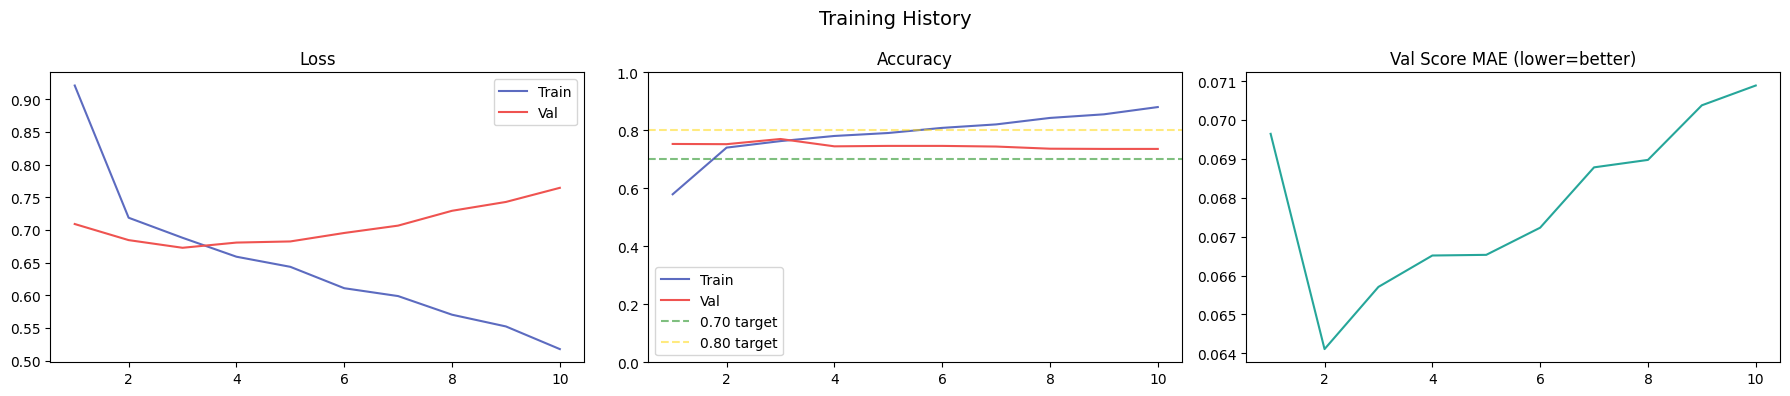

In [ ]:
ep = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(ep, history['train_loss'], label='Train', color='#5c6bc0')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#ef5350')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(ep, history['train_acc'], label='Train', color='#5c6bc0')
axes[1].plot(ep, history['val_acc'],   label='Val',   color='#ef5350')
axes[1].axhline(0.70, color='green', linestyle='--', alpha=0.5, label='0.70 target')
axes[1].axhline(0.80, color='gold',  linestyle='--', alpha=0.5, label='0.80 target')
axes[1].set_title('Accuracy'); axes[1].set_ylim(0,1); axes[1].legend()

axes[2].plot(ep, history['val_mae'], color='#26a69a')
axes[2].set_title('Val Score MAE (lower=better)')

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Test set evaluation (standard + TTA)

══════════════════════════════════════════════════
  TEST SET RESULTS (standard inference)
══════════════════════════════════════════════════
  Accuracy: 0.7686 (76.9%)
  Score MAE: 0.0658

  GOOD — above 0.70 target

              precision    recall  f1-score   support

      bad(0)     0.7991    0.8551    0.8262       428
  average(1)     0.6544    0.5553    0.6008       416
     good(2)     0.8180    0.8720    0.8441       500

    accuracy                         0.7686      1344
   macro avg     0.7572    0.7608    0.7570      1344
weighted avg     0.7614    0.7686    0.7631      1344



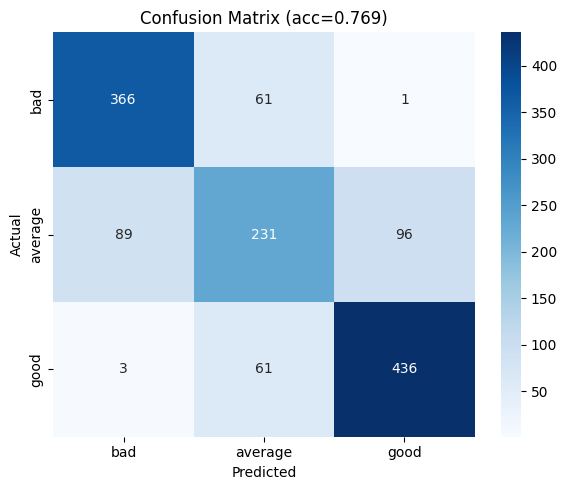

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(f'{OUTPUT_DIR}visual_scorer_best.pth', map_location=device))

# ── Standard evaluation
_, test_acc, test_mae, test_preds, test_labels = eval_one_epoch(model, test_loader)

print('═'*50)
print('  TEST SET RESULTS (standard inference)')
print('═'*50)
print(f'  Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'  Score MAE: {test_mae:.4f}')
print()

if test_acc >= 0.78:
    print('  EXCELLENT — above 0.78 target')
elif test_acc >= 0.70:
    print('  GOOD — above 0.70 target')
elif test_acc >= 0.60:
    print('  ACCEPTABLE — aesthetic scoring is subjective, 60%+ is solid')
else:
    print('  WEAK — try more epochs or unfreeze more backbone layers')

print()
print(classification_report(
    test_labels, test_preds,
    target_names=['bad(0)','average(1)','good(2)'],
    digits=4
))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['bad','average','good'],
            yticklabels=['bad','average','good'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (acc={test_acc:.3f})')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Test-Time Augmentation (TTA)
Averages predictions over 5 crops → squeezes extra 1–3% accuracy

In [ ]:
@torch.no_grad()
def predict_with_tta(model, df_split, attr_cols, n_crops=5):
    model.eval()
    all_preds, all_labels = [], []

    crop_tf = transforms.Compose([
        transforms.Resize((288,288)),
        transforms.FiveCrop(256),
        transforms.Lambda(lambda crops: torch.stack([
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])(
                transforms.ToTensor()(c)) for c in crops
        ]))
    ])

    for _, row in df_split.iterrows():
        img    = Image.open(row['img_path']).convert('RGB')
        crops  = crop_tf(img).to(device)          # (5, 3, 256, 256)
        attrs  = torch.tensor(
            [float(row[c]) for c in attr_cols], dtype=torch.float32
        ).unsqueeze(0).repeat(5,1).to(device)      # (5, n_attrs)

        logits_list = []
        for i in range(5):
            lo, _ = model(crops[i].unsqueeze(0), attrs[i].unsqueeze(0))
            logits_list.append(torch.softmax(lo, dim=1))

        avg_probs = torch.stack(logits_list).mean(0)
        pred = avg_probs.argmax(1).item()
        all_preds.append(pred)
        all_labels.append(int(row['label']))

    return all_labels, all_preds


print('Running TTA on test set (takes ~2 min)...')
tta_labels, tta_preds = predict_with_tta(model, test_df, ATTR_NORM)
tta_acc = accuracy_score(tta_labels, tta_preds)

print(f'\nTTA Accuracy: {tta_acc:.4f} ({tta_acc*100:.1f}%)')
print(f'Standard Acc: {test_acc:.4f}')
print(f'TTA gain:     +{(tta_acc-test_acc)*100:.2f}%')
print()
print(classification_report(
    tta_labels, tta_preds,
    target_names=['bad(0)','average(1)','good(2)'],
    digits=4
))

Running TTA on test set (takes ~2 min)...

TTA Accuracy: 0.7686 (76.9%)
Standard Acc: 0.7686
TTA gain:     +0.00%

              precision    recall  f1-score   support

      bad(0)     0.8048    0.8575    0.8303       428
  average(1)     0.6446    0.5841    0.6129       416
     good(2)     0.8278    0.8460    0.8368       500

    accuracy                         0.7686      1344
   macro avg     0.7591    0.7625    0.7600      1344
weighted avg     0.7638    0.7686    0.7654      1344



## Step 11 — Save everything

In [ ]:
model_config = {
    'architecture':    'EfficientNet-B2 + late attribute fusion',
    'num_classes':     3,
    'class_names':     ['bad', 'average', 'good'],
    'n_attrs':         N_ATTRS,
    'attr_cols_norm':  ATTR_NORM,
    'attr_cols_orig':  ATTR_COLS,
    'class_boundaries':{'q33': float(q33), 'q66': float(q66)},
    'test_accuracy_standard': float(round(test_acc, 4)),
    'test_accuracy_tta':      float(round(tta_acc,  4)),
    'test_score_mae':         float(round(test_mae,  4)),
    'best_val_accuracy':      float(round(best_val_acc, 4)),
    'input_size':      256,
    'normalize_mean':  [0.485, 0.456, 0.406],
    'normalize_std':   [0.229, 0.224, 0.225],
    'score_to_0_10':  'multiply score_n by 10',
}

with open(f'{OUTPUT_DIR}visual_model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print('Saved files:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    kb = os.path.getsize(f'{OUTPUT_DIR}{fname}')/1000
    print(f'  {fname:45s} {kb:8.1f} KB')

Saved files:
  .virtual_documents                                 4.1 KB
  attr_norm_stats.json                               0.6 KB
  attribute_importance.json                          0.4 KB
  confusion_matrix.png                              43.1 KB
  state.db                                      115990.8 KB
  training_curves.png                              111.9 KB
  visual_model_config.json                           1.0 KB
  visual_scorer_best.pth                         34921.5 KB


## Step 12 — Inference function for the app

In [ ]:
# Load the normalization stats (in production this would be loaded from disk)
with open(f'{OUTPUT_DIR}attr_norm_stats.json', 'r') as f:
    ATTR_NORM_STATS = json.load(f)

def normalize_attrs(raw_attrs_dict, norm_stats):
    """
    Normalize raw attribute values to [0,1] using training stats.

    Args:
        raw_attrs_dict: dict of {attribute_name: raw_value}
                        Raw values are in [-1, 1] range (AADB scale)
        norm_stats:     dict loaded from attr_norm_stats.json

    Returns:
        list of normalized float values in [0, 1]
    """
    normalized = []
    for col in ATTR_COLS:
        raw_val = float(raw_attrs_dict.get(col, 0.0))
        cmin = norm_stats[col]['min']
        cmax = norm_stats[col]['max']
        norm_val = (raw_val - cmin) / (cmax - cmin + 1e-8)
        norm_val = float(np.clip(norm_val, 0.0, 1.0))  # safety clamp
        normalized.append(norm_val)
    return normalized


def predict_aesthetic(image_path, raw_attrs_dict, model, device,
                      norm_stats=None, use_tta=True):
    """
    Predict aesthetic quality of an image.

    Args:
        image_path:     str — path to image file
        raw_attrs_dict: dict — raw AADB attribute scores in [-1, 1] range
                        e.g. {'ColorHarmony': 0.4, 'RuleOfThirds': 0.6, ...}
                        If an attribute is missing, 0.0 (neutral) is used.
                        Pass {} if no attributes available (image-only mode).
        model:          loaded AestheticFusionModel
        device:         torch device
        norm_stats:     dict loaded from attr_norm_stats.json
                        If None, loads from OUTPUT_DIR automatically.
        use_tta:        bool — use 5-crop TTA for better accuracy

    Returns:
        dict with class_label, score_0_10, confidence, class_probs
    """
    model.eval()

    # Load norm stats if not provided
    if norm_stats is None:
        with open(f'{OUTPUT_DIR}attr_norm_stats.json', 'r') as f:
            norm_stats = json.load(f)

    # Normalize attributes correctly
    attr_vals = normalize_attrs(raw_attrs_dict, norm_stats)
    attrs_t   = torch.tensor(attr_vals, dtype=torch.float32).unsqueeze(0).to(device)

    img = Image.open(image_path).convert('RGB')

    base_tf = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    if use_tta:
        crop_tf = transforms.Compose([
            transforms.Resize((288, 288)),
            transforms.FiveCrop(256),
            transforms.Lambda(lambda crops: torch.stack([
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(
                    transforms.ToTensor()(c)) for c in crops
            ]))
        ])
        crops = crop_tf(img).to(device)  # (5, 3, 256, 256)
        # Repeat attrs for all 5 crops
        attrs_5 = attrs_t.repeat(5, 1)  # (5, n_attrs)

        with torch.no_grad():
            # Batch all 5 crops in one forward pass (faster)
            logits_all, scores_all = model(crops, attrs_5)
            probs   = torch.softmax(logits_all, dim=1).mean(0).cpu().numpy()
            score_n = float(scores_all.mean().cpu().numpy())
    else:
        img_t = base_tf(img).unsqueeze(0).to(device)
        with torch.no_grad():
            logits, sc = model(img_t, attrs_t)
            probs   = torch.softmax(logits, dim=1)[0].cpu().numpy()
            score_n = float(sc.cpu().numpy()[0])

    class_id    = int(np.argmax(probs))
    class_names = ['bad', 'average', 'good']

    return {
        'class_label':  class_names[class_id],
        'class_id':     class_id,
        'score_0_10':   round(score_n * 10, 2),
        'confidence':   round(float(probs[class_id]), 4),
        'class_probs':  {
            'bad':     round(float(probs[0]), 4),
            'average': round(float(probs[1]), 4),
            'good':    round(float(probs[2]), 4),
        }
    }


# ── Test on 20 samples — should now match training accuracy (~76%)
print('Sample predictions (TTA + correct normalization):')
print(f'{"File":40s} | {"True":7s} | {"Pred":7s} | {"Score":5s} | {"Conf":5s}')
print('-' * 75)

correct = 0
samples = test_df.sample(20, random_state=7)

for _, row in samples.iterrows():
    # Pass RAW attribute values ([-1,1]) — normalization happens inside
    raw_attrs = {col: float(row[col]) for col in ATTR_COLS}
    result    = predict_aesthetic(
        row['img_path'], raw_attrs, model, device,
        norm_stats=ATTR_NORM_STATS, use_tta=True
    )
    true_cls  = ['bad', 'average', 'good'][int(row['label'])]
    match     = '✓' if result['class_label'] == true_cls else '✗'
    if result['class_label'] == true_cls:
        correct += 1
    print(
        f'{row["ImageFile"][:40]:40s} | {true_cls:7s} | '
        f'{result["class_label"]:7s} | {result["score_0_10"]:5.1f} | '
        f'{result["confidence"]:.3f} {match}'
    )

print(f'\nSample accuracy: {correct}/20 ({correct/20*100:.0f}%)')
print('Expected: ~15/20 (matches ~76% test accuracy)')

Sample predictions (TTA + correct normalization):
File                                     | True    | Pred    | Score | Conf 
---------------------------------------------------------------------------
farm1_397_19991490845_0a579b6530_b.jpg   | average | bad     |   4.2 | 0.610 ✗
farm1_519_19495062533_0ba50bc733_b.jpg   | bad     | bad     |   3.1 | 0.895 ✓
farm1_280_19956402259_b890664485_b.jpg   | good    | good    |   7.0 | 0.872 ✓
farm1_511_20174869785_543dbd32a5_b.jpg   | good    | good    |   7.6 | 0.955 ✓
farm1_330_20137445476_2573f6c027_b.jpg   | bad     | bad     |   3.8 | 0.725 ✓
farm1_339_20198412985_9dc9944b9c_b.jpg   | average | average |   5.5 | 0.619 ✓
farm4_3761_19936832960_8377845059_b.jpg  | good    | good    |   7.3 | 0.923 ✓
farm1_339_20236732726_d8f2b73b79_b.jpg   | good    | good    |   7.2 | 0.899 ✓
farm1_279_20095947301_d867615cae_b.jpg   | good    | good    |   6.9 | 0.849 ✓
farm1_317_19881724270_1375e46786_b.jpg   | average | bad     |   3.9 | 0.682 ✗
farm1_5

In [ ]:
# VISUAL MODULE — lightweight demo using visual_inference helpers
from visual_inference import extract_largest_rect_image, simple_image_quality_score
# Update path to a screenshot on your machine
screenshot = input('Enter the full path to your screenshot: ').strip()
if not screenshot:
    raise ValueError('Please enter a valid screenshot path.')
cropped = extract_largest_rect_image(screenshot)
print('Cropped image path:', cropped)
score = simple_image_quality_score(cropped)
print('Heuristic visual score:')
print(score)

# Step 13 — Visual Test Gallery: sample images with Grad-CAM overlays

This demo samples a few images from the `test` split, runs the model prediction
(`predict_aesthetic`) and Grad-CAM. For each image we show:

- Original image
- Grad-CAM for the predicted class (hot)
- Overlay of Grad-CAM on the image (jet)
- Grad-CAM for the `bad` class (cool) to contrast what the model *would* focus
  on if predicting low quality

Adjust `SAMPLE_N` below to increase/decrease the number of images displayed.

In [ ]:
# Visual test gallery
from xai_inference import compute_grad_cam, GradCAM
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

SAMPLE_N = 6  # number of images to show (set to <= len(test_df))
SAMPLE_N = min(SAMPLE_N, len(test_df))

samples = test_df.sample(n=SAMPLE_N, random_state=42)

fig = plt.figure(figsize=(16, SAMPLE_N * 3))
for idx, (_, row) in enumerate(samples.iterrows()):
    raw_attrs = {col: float(row[col]) for col in ATTR_COLS}

    # Prediction (use lightweight single-crop inference to save time)
    pred = predict_aesthetic(
        row['img_path'], raw_attrs, model, device, norm_stats=ATTR_NORM_STATS, use_tta=False
    )

    # Grad-CAM for predicted class (and also compute for 'bad' class for contrast)
    xai_res = compute_grad_cam(row['img_path'], raw_attrs, outputs_dir=OUTPUT_DIR, device=device)
    cam_pred = xai_res['gradcam_heatmap']

    # Prepare image + tensors for computing alternative class cams
    img_pil = Image.open(row['img_path']).convert('RGB').resize((256, 256))
    tf_base = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    img_t = tf_base(Image.open(row['img_path']).convert('RGB')).unsqueeze(0).to(device)
    attrs_t = torch.tensor(normalize_attrs(raw_attrs, ATTR_NORM_STATS), dtype=torch.float32).unsqueeze(0).to(device)

    grad = GradCAM(model, model.img_backbone[-1])
    cam_bad = grad.generate(img_t, attrs_t, class_id=0)
    cam_good = grad.generate(img_t, attrs_t, class_id=2)

    # Resize cams to 256x256
    def resize_cam(c):
        return np.kron(c, np.ones((256 // c.shape[0], 256 // c.shape[1])))

    cam_pred_r = resize_cam(cam_pred)
    cam_bad_r  = resize_cam(cam_bad)
    cam_good_r = resize_cam(cam_good)

    # Plot row: Original | Pred CAM | Overlay Pred | Bad CAM (contrast)
    ax0 = fig.add_subplot(SAMPLE_N, 4, idx * 4 + 1)
    ax0.imshow(img_pil); ax0.axis('off')
    ax0.set_title(f"{row['ImageFile'][:28]}\nPred: {pred['class_label']} {pred['score_0_10']}/10")

    ax1 = fig.add_subplot(SAMPLE_N, 4, idx * 4 + 2)
    ax1.imshow(cam_pred_r, cmap='hot'); ax1.axis('off')
    ax1.set_title('Grad-CAM (pred)')

    ax2 = fig.add_subplot(SAMPLE_N, 4, idx * 4 + 3)
    ax2.imshow(img_pil); ax2.imshow(cam_pred_r, cmap='jet', alpha=0.45); ax2.axis('off')
    ax2.set_title('Overlay (pred)')

    ax3 = fig.add_subplot(SAMPLE_N, 4, idx * 4 + 4)
    ax3.imshow(img_pil); ax3.imshow(cam_bad_r, cmap='cool', alpha=0.45); ax3.axis('off')
    ax3.set_title('Grad-CAM (bad)')

    # Print concise XAI summary below the row (in notebook output)
    print('\n' + '-'*80)
    print(f"File: {row['ImageFile']}  → True: {['bad','average','good'][int(row['label'])]}  |  Pred: {pred['class_label']} ({pred['score_0_10']}/10) | Conf: {pred['confidence']}")
    print('Top regions (pred):')
    for d in xai_res['top_regions_description']:
        print('  -', d)

plt.tight_layout()
plt.show()

NameError: name 'test_df' is not defined